In [2]:
from pathlib import Path
import json

import pandas as pd
import numpy as np


run_dir = Path(".").resolve() / "runs" / "runs"


# names = [
#     "exp_aggregation_2ae9865c86_Bikes_20260817_131836",
#     "exp_aggregation_6ba3a8c889_Svhn_20260817_131836",
#     "exp_aggregation_97e9f1e345_Cifar10_20260817_131836",
#     "exp_aggregation_63536f9c1b_Energy_20260817_131836",
# ]

names = [
    "exp_ambiguity_gradient_b39c02fc0a_Bikes_20260819_154050",
    "exp_ambiguity_gradient_ca1fe8e38d_Energy_20260819_154050",
    "exp_ambiguity_gradient_d2f60c72f9_Cifar10_20260819_154050",
    "exp_ambiguity_gradient_08ba21ef89_Svhn_20260819_154050",
]


def parse_value(value):
    try:
        return int(value)
    except ValueError:
        return value


def parse_stem(path):
    stem = path.stem.removesuffix("_metrics")
    parts = stem.split("_")

    if len(parts) % 2 != 0:
        raise ValueError(f"Expected key_value pairs, got: {path.name}")

    return {
        parts[i]: parse_value(parts[i + 1])
        for i in range(0, len(parts), 2)
    }

dfs = []

for name in names:
    exp_dir = run_dir / name
    metric_files = sorted(exp_dir.glob("*_metrics.json"))

    parse_name = name.replace("ambiguity_gradient", "gradient")

    _, exp_type, launch_id, task, t1, t2 = parse_name.split("_")

    for path in metric_files:
        info = parse_stem(path)

        with path.open() as f:

            try:
                metrics = json.load(f)
            except json.JSONDecodeError:
                print(f"Cannot decode {path}")
                continue

        metrics = {
            k: np.asarray(v)
            for k, v in metrics.items()
        }

        shapes = {k: v.shape for k, v in metrics.items()}

        if len(set(shapes.values())) != 1:
            raise ValueError(
                f"Metric shapes differ in {path.name}: {shapes}"
            )

        shape = next(iter(shapes.values()))

        if len(shape) != 2:
            raise ValueError(
                f"Expected metrics shaped (epoch, seed), got {shape} "
                f"in {path.name}"
            )

        n_epochs, n_seeds = shape

        # Flatten in row-major order:
        # epoch 0 seed 0..N, epoch 1 seed 0..N, ...
        metrics_df = pd.DataFrame({
            k: v.reshape(-1)
            for k, v in metrics.items()
        })

        metrics_df["epoch"] = np.repeat(
            np.arange(n_epochs),
            n_seeds,
        )

        metrics_df["seed_id"] = np.tile(
            np.arange(n_seeds),
            n_epochs,
        )

        metrics_df["run_id"] = info.pop("run")
        metrics_df["task"] = task


        for key, value in info.items():
            metrics_df[key] = value

        # metrics_df["experiment"] = name

        dfs.append(metrics_df)


df = pd.concat(dfs, ignore_index=True)

df = df.sort_values(
    ["run_id", "seed_id", "epoch"]
).reset_index(drop=True)



def mean_seeds(df: pd.DataFrame):
    from pandas.api.types import is_string_dtype

    mean_columns = tuple(df.dtypes.index[df.dtypes == float])
    take_columns = tuple((set(df.dtypes.index[df.dtypes == int]) | set(df.dtypes.index[df.dtypes.apply(is_string_dtype)])) - {"seed_id"})

    group_cols = ["task", "epoch", "run_id"]
    take_columns = tuple(set(take_columns) - set(group_cols))
    mean_columns = tuple(set(mean_columns) - set(group_cols))

    g = df.groupby(group_cols, observed=True)

    nunique = g[list(take_columns)].nunique(dropna=False)
    assert (nunique <= 1).all().all(), f"Non-unique values:\n{nunique[nunique.gt(1).any(axis=1)]}"

    return g.agg(
        **{c: (c, "mean") for c in mean_columns},
        **{c: (c, "first") for c in take_columns},
    ).reset_index()

df: pd.DataFrame = df.pipe(mean_seeds)

Cannot decode /home/viktor/Documents/liquid/liquid_jax/runs/runs/exp_ambiguity_gradient_08ba21ef89_Svhn_20260819_154050/run_00107_predictors_4_delegators_8_pwidth_16_dwidth_4_mixing_product_ambiguity_delegators_metrics.json


In [3]:
task_baseline_losses = (
    df
    .groupby("task")["performance_loss"].max()
)

baseline = df["task"].map(task_baseline_losses)

df["performance_loss_casted"] = df["performance_loss"] / baseline
df["validation_performance_loss_casted"] = (
    df["validation_performance_loss"] / baseline
)

In [17]:
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(df.groupby(["task", "run_id"]).size().unstack())

run_id,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300
task,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Bikes,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0
Cifar10,500.0,500.0,500.0,500.0,500.0,500.0,500.0,500.0,500.0,500.0,500.0,500.0,500.0,500.0,500.0,500.0,500.0,500.0,500.0,500.0,500.0,500.0,500.0,500.0,500.0,500.0,500.0,500.0,500.0,500.0,50

In [3]:
df.groupby(["task", "run_id"]).size().unstack().isnull().any().any()

np.True_

In [ ]:
df.groupby(["task", "run_id"])

In [5]:
df.memory_usage().sum() / 1_000_000_000

np.float64(0.23301192)

In [33]:
df["task"].value_counts()

task
Bikes      1500000
Energy     1000000
Cifar10      42500
Svhn         29500
Name: count, dtype: int64

In [4]:
exp_vars = ["predictors", "delegators", "pwidth", "dwidth"]
var_oi = "ambiguity" # "mixing"
var_oi_values = df[var_oi].unique().tolist() # ["product", "sum"]
val_loss_col = "validation_performance_loss_casted"
train_loss_col = "performance_loss_casted"
higher_better = False

def get_metric_col(task):
    if task in {"Cifar10", "Svhn"}:
        return "validation_accuracy_metric"
    elif task in {"Bikes", "Energy"}:
        return "validation_r2_metric" 
    else:
        raise ValueError(f"Unknown task {task}")

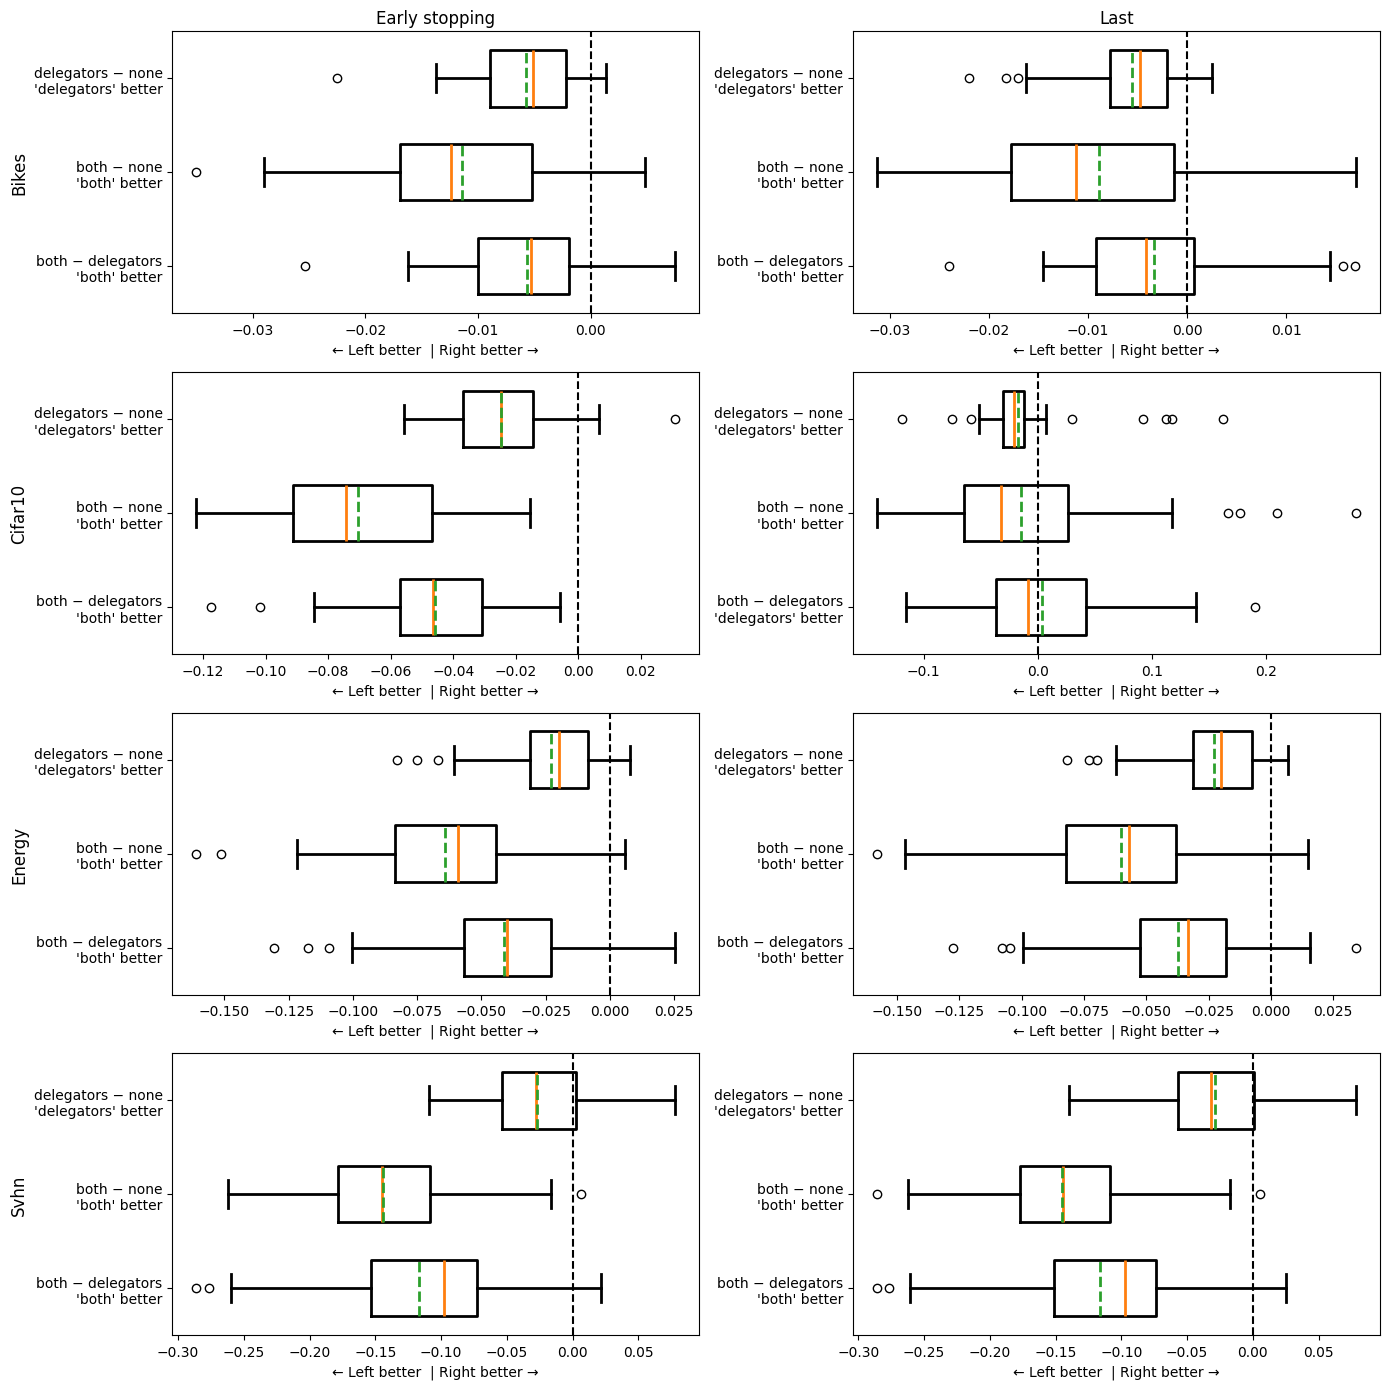

In [6]:
from typing import Literal

from matplotlib import pyplot as plt


def pair_up(df: pd.DataFrame, single_task: bool =True):
    if single_task:
        return _pair_up(df)
    else:
        out = []
        for task, task_df in df.groupby("task"):
            out.append(_pair_up(task_df, prefix_with=task))
        return pd.concat(out, ignore_index=True)

def _pair_up(single_task: pd.DataFrame, prefix_with: str = ""):

    n_in_pair = len(var_oi_values)

    if n_in_pair < 1:
        raise ValueError("n_in_pair must be >= 1")

    if single_task.duplicated("run_id").any():
        raise ValueError("Run id duplicates")

    single_task = single_task.copy()

    # Intended groups: (1,2), (3,4), ...
    single_task["pair_id"] = (single_task["run_id"] - 1) // n_in_pair
    single_task["pair_id"] = single_task["pair_id"].astype("string")

    if prefix_with:
        single_task["pair_id"] = prefix_with + "_" + single_task["pair_id"] 

    # Delete groups with missing runs
    complete_pairs = (
        single_task.groupby("pair_id")["run_id"]
        .nunique()
        .eq(n_in_pair)
    )

    single_task = single_task[
        single_task["pair_id"].isin(complete_pairs.index[complete_pairs])
    ].copy()

    inconsistent = (
        single_task.groupby("pair_id")[exp_vars]
        .nunique(dropna=False)
        .gt(1)
        .any(axis=1)
    )

    if inconsistent.any():
        bad = inconsistent.index[inconsistent].tolist()
        raise ValueError(f"Pairs contain inconsistent exp_vars: {bad}")

    return single_task.reset_index(drop=True)

def select_last(df: pd.DataFrame):
    return (
        df
        .sort_values(["task", "run_id", "epoch"])
        .groupby(["task", "run_id"])
        .tail(1)
    )


def select_early_stopping(df: pd.DataFrame):
    idx = (
        df
        .groupby(["task", "run_id"])[val_loss_col]
        .idxmin()
    )
    return df.loc[idx].copy()

def pivot_to_metrics(paired: pd.DataFrame, *cols: str):

    cols = list(cols)

    if len(cols) == 0:
        cols = [val_loss_col]

    if len(cols) == 1:
        cols = cols[0]

    return pd.pivot(paired, index="pair_id", columns=var_oi, values=cols)
    

def plot_relative_diff(
    pivot: pd.DataFrame,
    ax,
    lw: int = 2,
):
    from itertools import combinations

    data = []
    labels = []

    for l, r in combinations(var_oi_values, 2):
        l_vals = pivot[l]
        r_vals = pivot[r]

       
        diff = l_vals - r_vals
       
        diff = diff.dropna()
        mean_diff = diff.mean()

        if mean_diff == 0:
            better = "tie"
        elif not higher_better:
            better = l if mean_diff < 0 else r
        else:
            better = l if mean_diff > 0 else r

        data.append(diff)

        labels.append(
            f"{l} − {r}\n"
            f"'{better}' better"
        )

    ax.boxplot(
        data,
        vert=False,
        tick_labels=labels,
        widths=0.6,
        showmeans=True,
        meanline=True,
        boxprops={"linewidth": lw},
        whiskerprops={"linewidth": lw},
        capprops={"linewidth": lw},
        medianprops={"linewidth": lw},
        meanprops={"linewidth": lw, "linestyle": "--"},
    )

    ax.axvline(0, color="black", linestyle="dashed")

    if (not higher_better):
        ax.set_xlabel(
            "← Left better  | Right better →"
        )
    else:
        ax.set_xlabel(
            "← Right better | Left better →"
        )

fig, axs = plt.subplots(4, 2, figsize=(14, 14))

axs[0, 0].set_title("Early stopping")
axs[0, 1].set_title("Last")

for i_task, (task, task_df) in enumerate(df.groupby("task")):
    axl, axr = axs[i_task, :]

    (
        task_df
        .pipe(select_early_stopping)
        .pipe(pair_up)
        .pipe(pivot_to_metrics)
        .pipe(lambda x: plot_relative_diff(x, axl))
    )

    (
        task_df
        .pipe(select_last)
        .pipe(pair_up)
        .pipe(pivot_to_metrics)
        .pipe(lambda x: plot_relative_diff(x, axr))
    )

    axl.set_ylabel(task, fontsize=12)

fig.tight_layout()


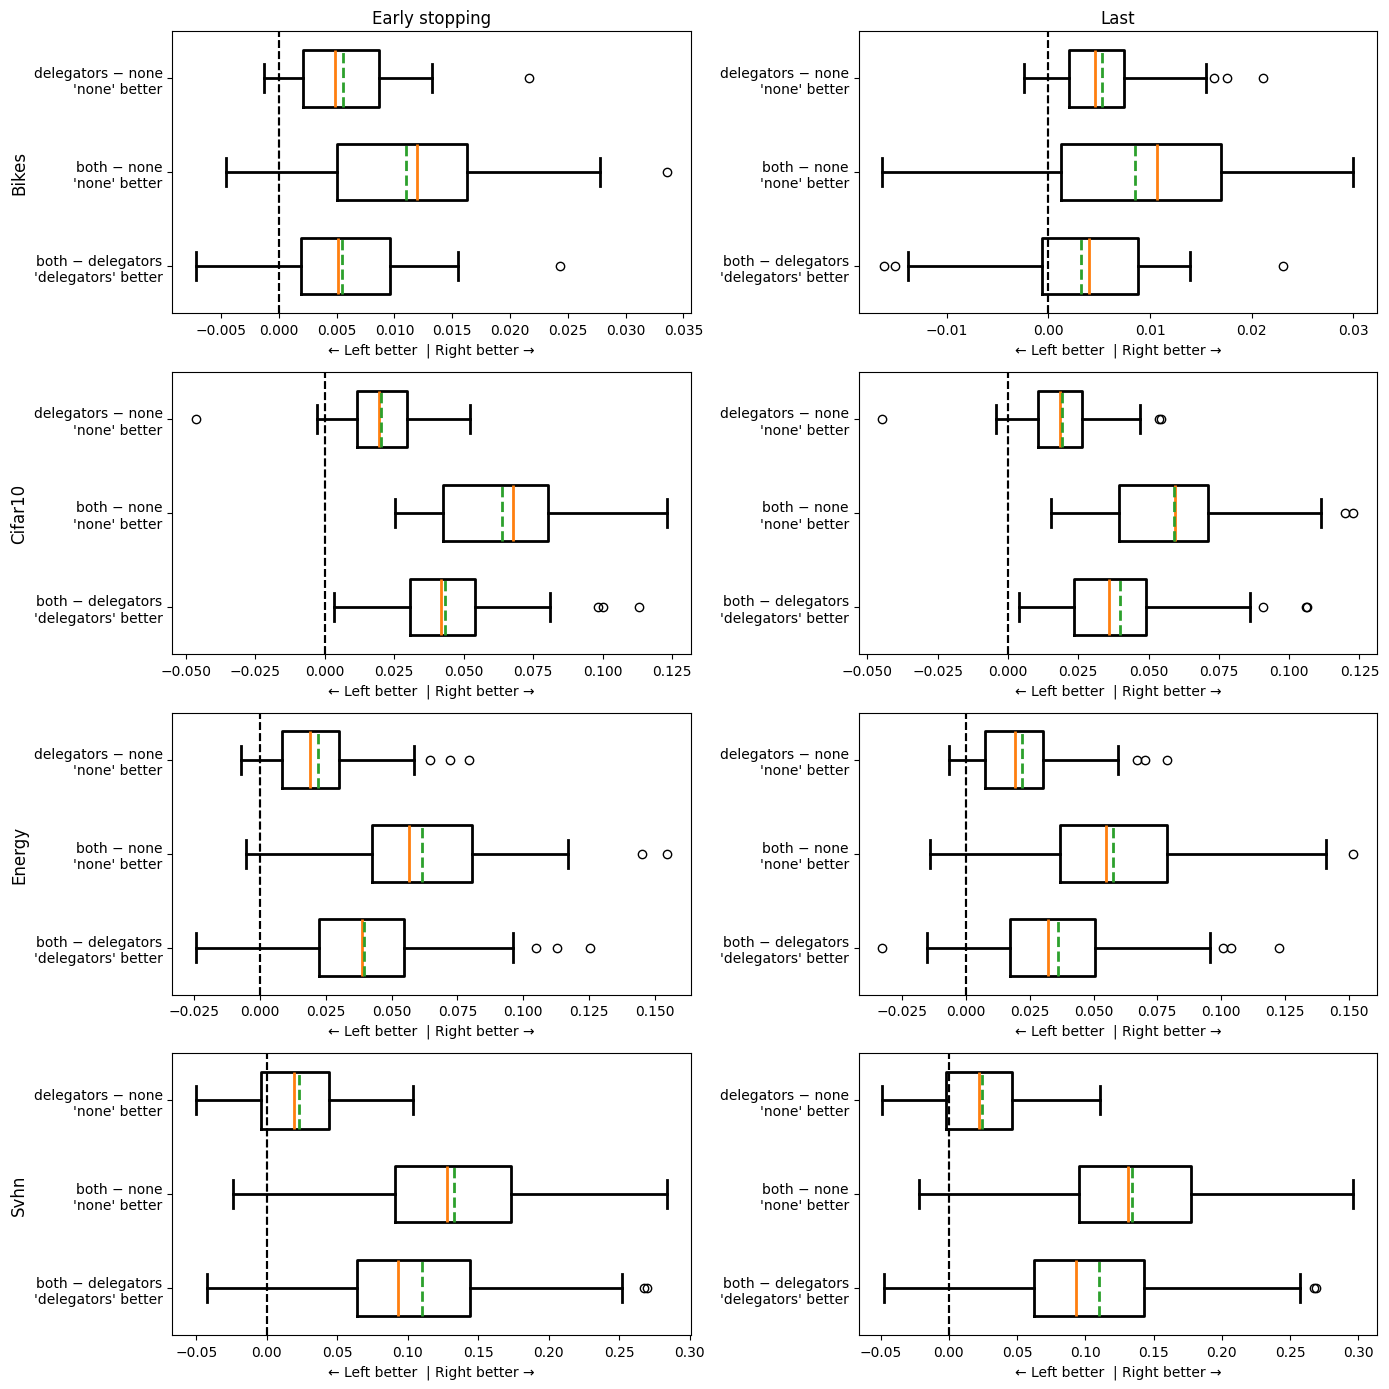

In [7]:
fig, axs = plt.subplots(4, 2, figsize=(14, 14))

axs[0, 0].set_title("Early stopping")
axs[0, 1].set_title("Last")

for i_task, (task, task_df) in enumerate(df.groupby("task")):

    axl, axr = axs[i_task, :]

    task_df.pipe(select_early_stopping).pipe(pair_up).pipe(lambda df: pivot_to_metrics(df, get_metric_col(task))).pipe(lambda df: plot_relative_diff(df, axl))
    task_df.pipe(select_last).pipe(pair_up).pipe(lambda df: pivot_to_metrics(df, get_metric_col(task))).pipe(lambda df: plot_relative_diff(df, axr))

    axl.axvline(0, color="black", linestyle="dashed")
    axr.axvline(0, color="black", linestyle="dashed")

    axl.set_ylabel(task, fontsize=12)

fig.tight_layout()

### Gradient experiment: is delegator only condition better with increasing sizes of predictors? 

In [8]:
paired = (
        df
        .pipe(select_early_stopping)
        .pipe(lambda df: pair_up(df, single_task=False))
        .pipe(lambda df: pivot_to_metrics(df, val_loss_col, train_loss_col, "pwidth"))
    )

paired

validation_performance_loss_casted                       \
ambiguity                               both delegators      none   
pair_id                                                             
Bikes_0                             0.049584   0.042097  0.045477   
Bikes_1                             0.059956   0.074317  0.079329   
Bikes_10                            0.046417   0.058419  0.067834   
Bikes_11                            0.052045   0.056294  0.059975   
Bikes_12                            0.043071   0.050747  0.058733   
...                                      ...        ...       ...   
Svhn_95                             0.366424   0.366123  0.417744   
Svhn_96                             0.443936   0.655652  0.659425   
Svhn_97                             0.495775   0.702107  0.664555   
Svhn_98                             0.300409   0.367597  0.421955   
Svhn_99                             0.503466   0.656189  0.762352   

          performance_loss_casted                      pwidth                   
ambiguity                    both delegators      none   both delegators  none  
pair_id                                                                         
Bikes_0                  0.009541   0.010831  0.014517   16.0       16.0  16.0  
Bikes_1                  0.026215   0.048583  0.060005    4.0        4.0   4.0  
Bikes_10                 0.017106   0.023533  0.036192    4.0        4.0   4.0  
Bikes_11                 0.015232   0.026308  0.026467   16.0       16.0  16.0  
Bikes_12                 0.009626   0.013503  0.019558   16.0       16.0  16.0  
...                           ...        ...       ...    ...        ...   ...  
Svhn_95                  0.347311   0.349250  0.397082   16.0       16.0  16.0  
Svhn_96                  0.425932   0.654716  0.662268    4.0        4.0   4.0  
Svhn_97                  0.484286   0.703662  0.666581    4.0        4.0   4.0  
Svhn_98                  0.265926   0.340238  0.402604   16.0       16.0  16.0  
Svhn_99                  0.497932   0.643641  0.764053    4.0        4.0   4.0  

[399 rows x 9 columns]

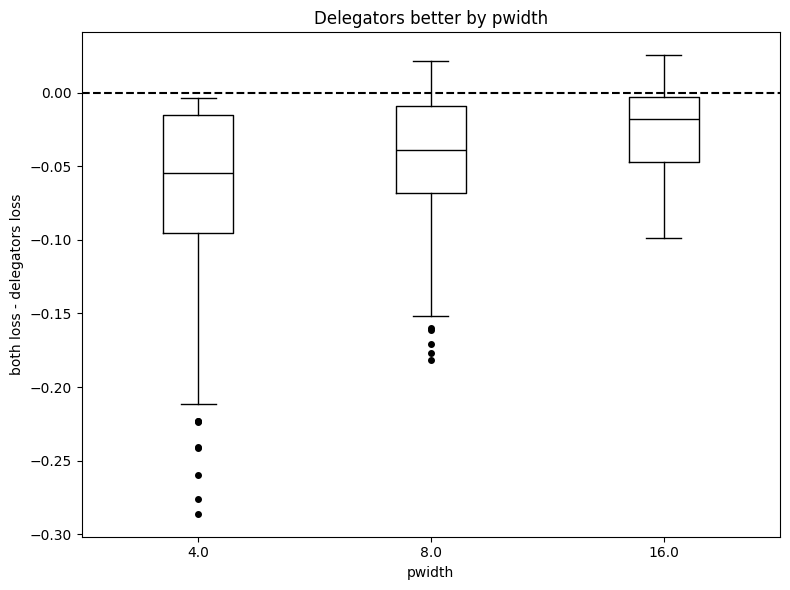

In [9]:
delegators_better = paired[(val_loss_col, "both")] - paired[(val_loss_col, "delegators")]
pwidth = paired[("pwidth", "none")]

grouped = delegators_better.groupby(pwidth, sort=True)

labels = [str(k) for k, _ in grouped]
data = [v.dropna().to_numpy() for _, v in grouped]

fig, ax = plt.subplots(figsize=(8, 6))

ax.boxplot(
    data,
    tick_labels=labels,
    vert=True,
    boxprops=dict(color="black"),
    whiskerprops=dict(color="black"),
    capprops=dict(color="black"),
    medianprops=dict(color="black"),
    flierprops=dict(
        marker="o",
        markeredgecolor="black",
        markerfacecolor="black",
        markersize=4,
    ),
)

ax.axhline(0, color="black", linestyle="dashed")
ax.set_xlabel("pwidth")
ax.set_ylabel("both loss - delegators loss")
ax.set_title("Delegators better by pwidth")

plt.tight_layout()
plt.show()

Opa we can see clear trend supporting theory: as the predictors get more capable (perfect intrepolators) the delegator condition becomes more viable. The theory that one should not explicitly maximize variance (condition "both") mostly applies when the predictors are perfect interpolators.

Lets check it a bit more precisely with a performance training loss

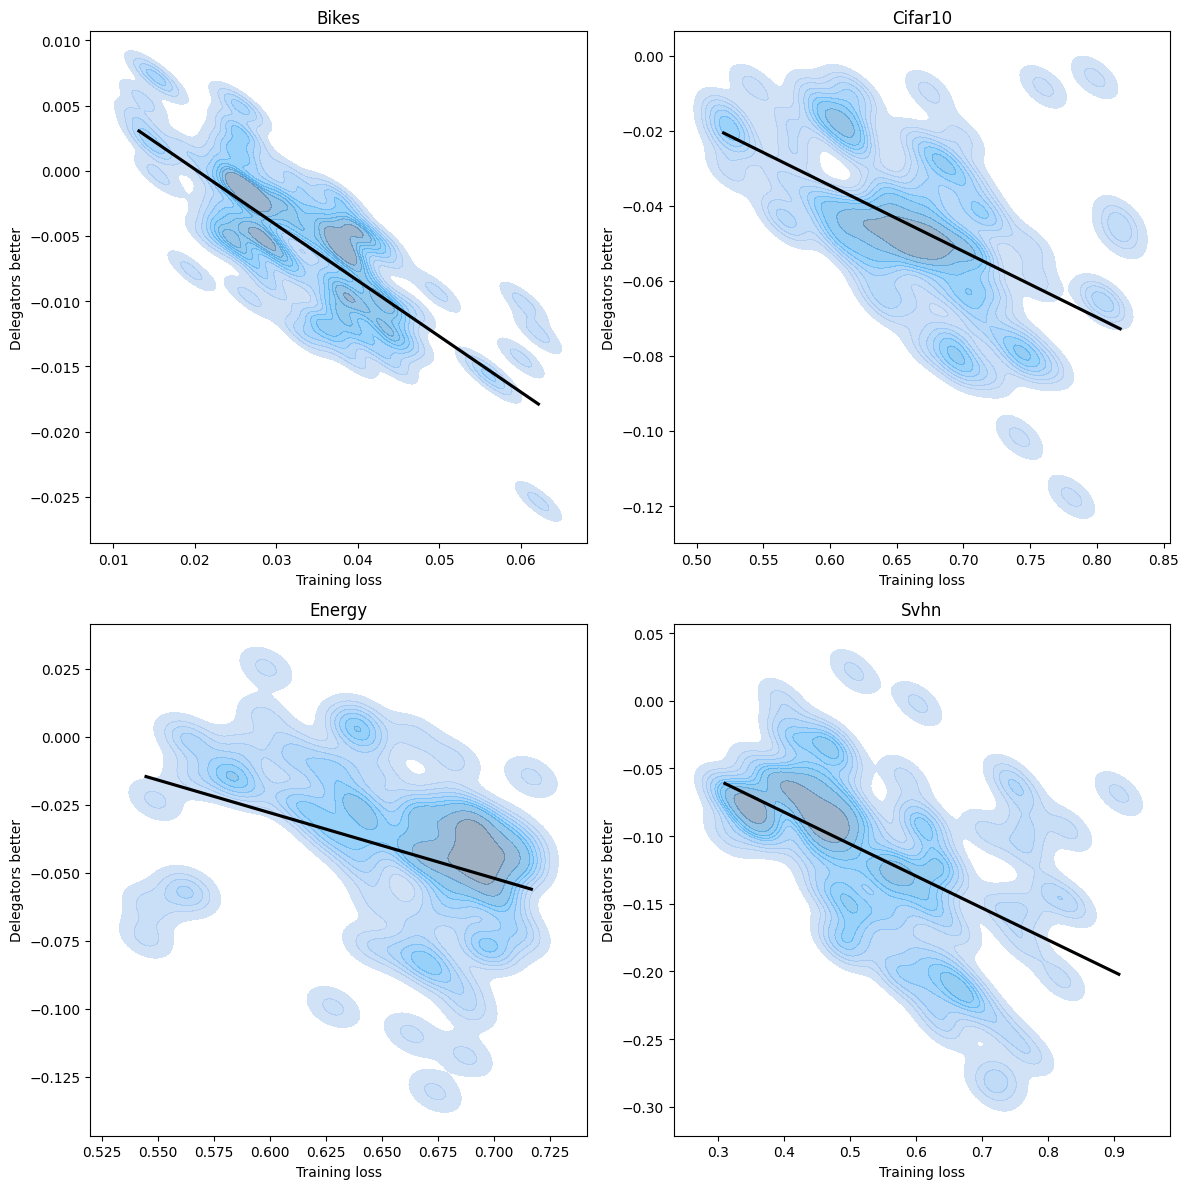

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

tasks = paired.index.to_series().str.split("_").str[0].unique()

fig, axes = plt.subplots(2, 2, figsize=(12, 12))

for task, ax in zip(tasks, axes.flat):
    mask = paired.index.to_series().str.startswith(f"{task}_")

    training_loss = paired.loc[mask, ("performance_loss_casted", "none")]
    delegators_better_task = delegators_better.loc[mask]

    sns.kdeplot(
        x=training_loss,
        y=delegators_better_task,
        fill=True,
        alpha=.5,
        ax=ax,
        bw_adjust=0.4,
    )
    sns.regplot(
        x=training_loss,
        y=delegators_better_task,
        scatter=False,
        ci=None,
        ax=ax,
        color="black",
    )

    ax.set_title(task)
    ax.set_xlabel("Training loss")
    ax.set_ylabel("Delegators better")

plt.tight_layout()

<Axes: ylabel='Density'>

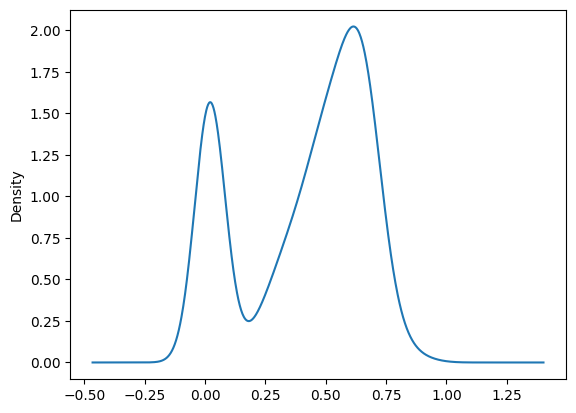

In [14]:
select_last(df)[train_loss_col].plot.density()

In [102]:
df.groupby("run_id").size()

run_id
1      21000
2      21000
3      21000
4      21000
5      21000
       ...  
296    21000
297    21000
298    21000
299    21000
300    21000
Length: 300, dtype: int64